### Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import kagglehub


### Step 1: Download ORL Dataset

In [6]:
# Download latest version
path = kagglehub.dataset_download("kasikrit/att-database-of-faces")
print("Path to dataset files:", path)


Path to dataset files: C:\Users\Kimo Store\.cache\kagglehub\datasets\kasikrit\att-database-of-faces\versions\2


### Step 2: Generate the Data Matrix and the Label vector

In the AT&T Face Dataset, a subject refers to a person. The dataset includes 40 different people, and each one is stored in a separate folder
Reading all 400 images (10 per person × 40 people)
Storing them in images (shape: 400, 112, 92)
Assigning a label (person ID) from 1 to 40 to each image

In [7]:
images = [] # data matrix
Y = []  # label vector

# Loop through subjects (s1 to s40)
for subject_id in range(1, 41): 
    subject_folder = os.path.join(path, f's{subject_id}')
    
    # Loop through each of the 10 images for the subject
    for img_number in range(1, 11):  # 1.pgm to 10.pgm
        img_path = os.path.join(subject_folder, f'{img_number}.pgm')
        
        # Read image 
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        # Append image and label
        images.append(img)
        Y.append(subject_id)  # Use subject_id as the label

images = np.array(images)        
Y = np.array(Y) 
D = images.reshape(400, -1)
D.shape

print("Loaded dataset shape:", D.shape)
print("Y shape:", Y.shape)


Loaded dataset shape: (400, 10304)
Y shape: (400,)


### Step 3: Split the Dataset into Training and Test sets

In [8]:
# Select training and testing rows
D_train = D[::2]  # odd-numbered rows
D_test  = D[1::2] # even-numbered rows 

y_train = Y[::2]
y_test  = Y[1::2]

print("Training set shape:", D_train.shape)
print("Testing set shape:", D_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)
print(y_train.max(), y_train.min())

Training set shape: (200, 10304)
Testing set shape: (200, 10304)
Training labels shape: (200,)
Testing labels shape: (200,)
40 1


### PCA Implementation

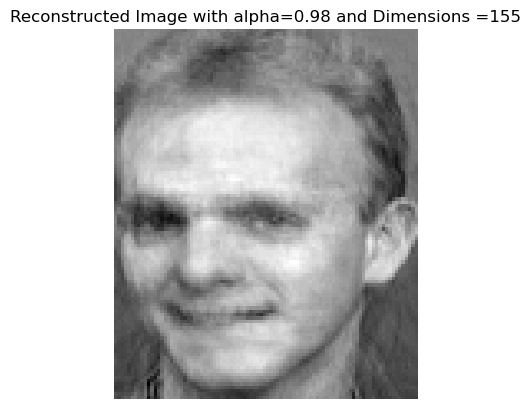

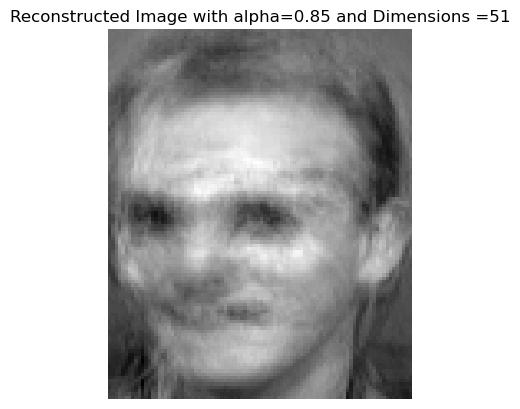

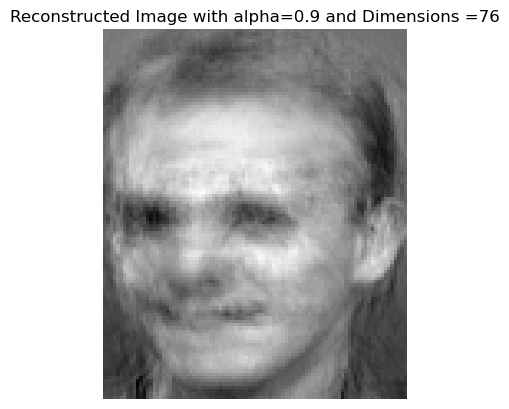

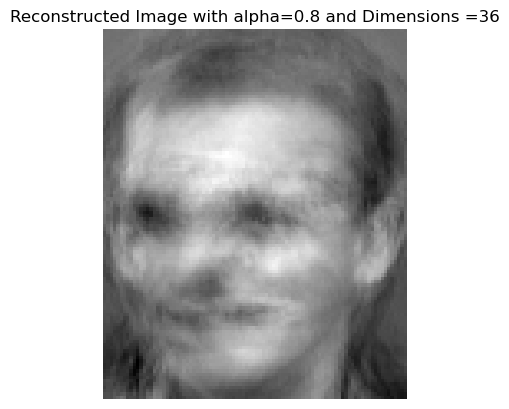

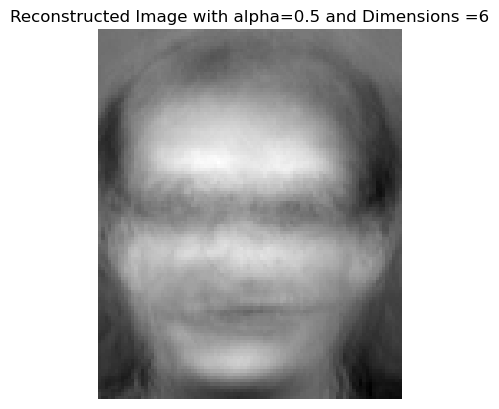

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import matplotlib.offsetbox as offsetbox

class PCA:
    def __init__(self, D_train, D_test, y_train, y_test):
        """Class intialization"""
        self.D_train = D_train
        self.D_test = D_test
        self.y_train = y_train
        self.y_test = y_test
        self.D_centered = []
        self.eigenvalues = []
        self.eigenvectors = []

    def compCov(self):
        """Compute the covariance matrix"""
        mean_face = np.mean(self.D_train, axis=0)
        self.D_centered = self.D_train - mean_face
        Cov = self.D_centered @ self.D_centered.T
        Cov = Cov / self.D_train.shape[0]
        return Cov

    def compEig(self, Cov):
        """Compute the eigenvalues and the eigenvectors in feature space"""
        eigenvalues, eigenvectors = np.linalg.eigh(Cov)
        eigenvalues = eigenvalues[::-1]
        eigenvectors = eigenvectors[:, ::-1]

        # Convert to feature space
        eigvecs_feat_space = self.D_centered.T @ eigenvectors 
        eigvecs_feat_space = eigvecs_feat_space[:, :len(eigenvalues)]  # reduce to same k

        norm_eigenvect = eigvecs_feat_space / np.linalg.norm(eigvecs_feat_space, axis=0)

        self.eigenvalues = eigenvalues
        self.eigenvectors = norm_eigenvect


    def selectComp(self, alpha):
        """Select the first i eigenvectors based on the explained variance"""
        sum = 0
        eigsum = np.sum(self.eigenvalues)
        for i, val in enumerate(self.eigenvalues):
            sum += val
            if sum / eigsum >= alpha:
                return self.eigenvectors[:, :i+1]

    def project(self, alpha):
        """Project the data on the eigenvectors"""
        Cov = self.compCov()
        self.compEig(Cov)
        eigvec = self.selectComp(alpha)
        proj = self.D_centered @ eigvec
        return proj , eigvec

    def visualize_projection(self, alpha, image_shape=(112, 92)):
        """Image reconstruction"""
        projected , subeigvec = self.project(alpha)
        recon = projected[22] @ subeigvec.T
        mean_face = np.mean(self.D_train, axis=0)
        recon_image = recon + mean_face
        recon_image = recon_image.reshape(image_shape)

        plt.imshow(recon_image, cmap='gray')
        plt.title(f"Reconstructed Image with alpha={alpha} and Dimensions ={projected.shape[1]}")
        plt.axis('off')
        plt.show()


pca = PCA(D_train, D_test, y_train, y_test)
pca.visualize_projection(alpha=0.98)
pca.visualize_projection(alpha=0.85)
pca.visualize_projection(alpha=0.9)
pca.visualize_projection(alpha=0.8)
pca.visualize_projection(alpha=0.5)


## Unsupervised Clustering
### K-Means Clustering

In [10]:
class KMeans:
    def __init__(self, n_clusters, max_iter=100):
        """Class initialization"""
        self.n_clusters = n_clusters
        self.max_iter = max_iter

    def fit(self, X):
        """Fit the KMeans model to the data"""
        # Randomly initialize centroids
        np.random.seed(42)
        indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)  # Randomly select initial centroids
        self.centroids = X[indices]
        
        for _ in range(self.max_iter):
            # Compute distances from each point to each centroid
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels_ = np.argmin(distances, axis=1) + 1  # Shift labels to start from 1
            
            new_centroids = np.array([
                X[self.labels_ == i].mean(axis=0) if np.any(self.labels_ == i) else self.centroids[i - 1]
                for i in range(1, self.n_clusters + 1)
            ])
            
            # Check for convergence
            if np.allclose(self.centroids, new_centroids):
                break

            self.centroids = new_centroids
            
            # print("Updated centroids:\n", self.centroids)
            # print("Updated labels:\n", self.labels_)
            # print("Updated centroids shape:", self.centroids.shape)
            # print("Updated labels shape:", self.labels_.shape)
            

    def predict(self, X):
        """Predict the closest cluster each sample in X belongs to"""
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1) + 1  # Shift labels to start from 1


### K-Means Clustering Evaluation

In [11]:
from sklearn.metrics import confusion_matrix, f1_score
from scipy.optimize import linear_sum_assignment

def clustering_accuracy(y_true, y_pred):
    """Compute clustering accuracy using the Hungarian algorithm"""
    D = max(y_pred.max(), y_true.max()) + 1 # Number of clusters
    # print("Number of clusters:", D)
    # Initialize the cost matrix
    cost = np.zeros((D, D), dtype=int)
    
    # Count the number of points assigned to each cluster
    for i in range(len(y_pred)):
        cost[y_pred[i], y_true[i]] += 1
        
    row_ind, col_ind = linear_sum_assignment(cost.max() - cost)
    total_correct = sum(cost[i, j] for i, j in zip(row_ind, col_ind))   # 
    
    # print("Cost matrix:\n", cost)
    # print("Cost matrix shape:", cost.shape)
    # print("Row indices:", row_ind)
    # print("Column indices:", col_ind)
    # print("Total correct assignments:", total_correct)
    # print("---------------------------------------------------------")
    return total_correct / len(y_pred)


### Run K-Means for different alpha and K

In [12]:
results_kmeans = []

for alpha in [0.8, 0.85, 0.9, 0.95]:
    reduced_data, eigvecs = pca.project(alpha)

    for K in [20, 40, 60]:
        kmeans = KMeans(n_clusters=K)
        kmeans.fit(reduced_data)

        acc = clustering_accuracy(pca.y_train, kmeans.labels_)
        results_kmeans.append((alpha, K, acc))
        print(f"Alpha: {alpha}, K: {K}, Accuracy: {acc:.4f}")
    print("--------------------------------------")



Alpha: 0.8, K: 20, Accuracy: 0.4050
Alpha: 0.8, K: 40, Accuracy: 0.6700
Alpha: 0.8, K: 60, Accuracy: 0.6700
--------------------------------------
Alpha: 0.85, K: 20, Accuracy: 0.4050
Alpha: 0.85, K: 40, Accuracy: 0.6600
Alpha: 0.85, K: 60, Accuracy: 0.6850
--------------------------------------
Alpha: 0.9, K: 20, Accuracy: 0.4050
Alpha: 0.9, K: 40, Accuracy: 0.6450
Alpha: 0.9, K: 60, Accuracy: 0.6450
--------------------------------------
Alpha: 0.95, K: 20, Accuracy: 0.3950
Alpha: 0.95, K: 40, Accuracy: 0.6450
Alpha: 0.95, K: 60, Accuracy: 0.6450
--------------------------------------


###  Plot Accuracy vs K and Alpha (K-Means)

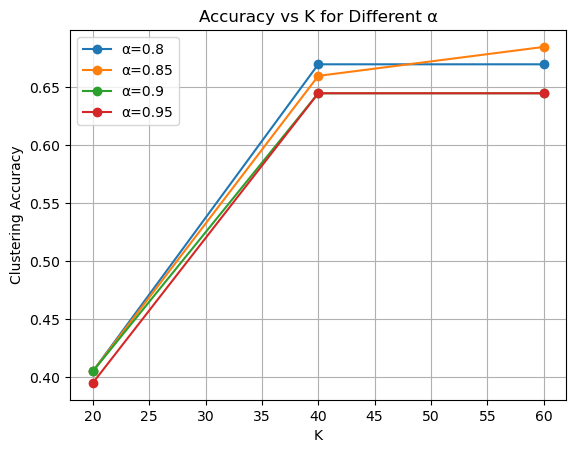

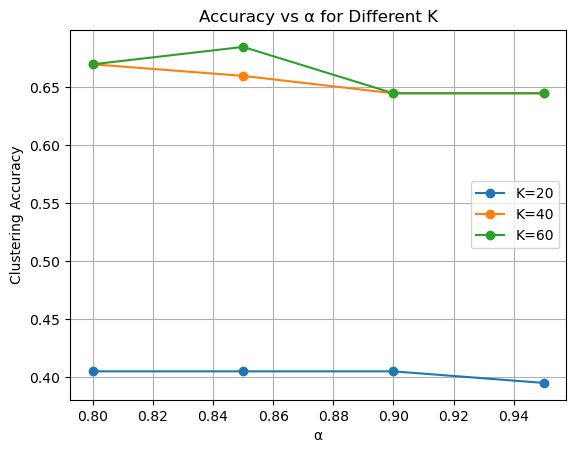

In [13]:
import matplotlib.pyplot as plt

for alpha in [0.8, 0.85, 0.9, 0.95]:
    accs = [acc for a, k, acc in results_kmeans if a == alpha]
    ks = [k for a, k, acc in results_kmeans if a == alpha]
    plt.plot(ks, accs, marker='o', label=f'α={alpha}')

plt.xlabel('K')
plt.ylabel('Clustering Accuracy')
plt.title('Accuracy vs K for Different α')
plt.legend()
plt.grid()
plt.show()

for k in [20, 40, 60]:
    accs = [acc for a, k_val, acc in results_kmeans if k_val == k]
    alphas = [a for a, k_val, acc in results_kmeans if k_val == k]
    plt.plot(alphas, accs, marker='o', label=f'K={k}')
    

plt.xlabel('α')
plt.ylabel('Clustering Accuracy')
plt.title('Accuracy vs α for Different K')  
plt.legend()
plt.grid()
plt.show()


### Evaluate Best Model on Test Set

Best alpha: 0.85, Best K: 60, Accuracy: 0.6850
Test Accuracy: 0.7400
Test F1 Score: 0.0188


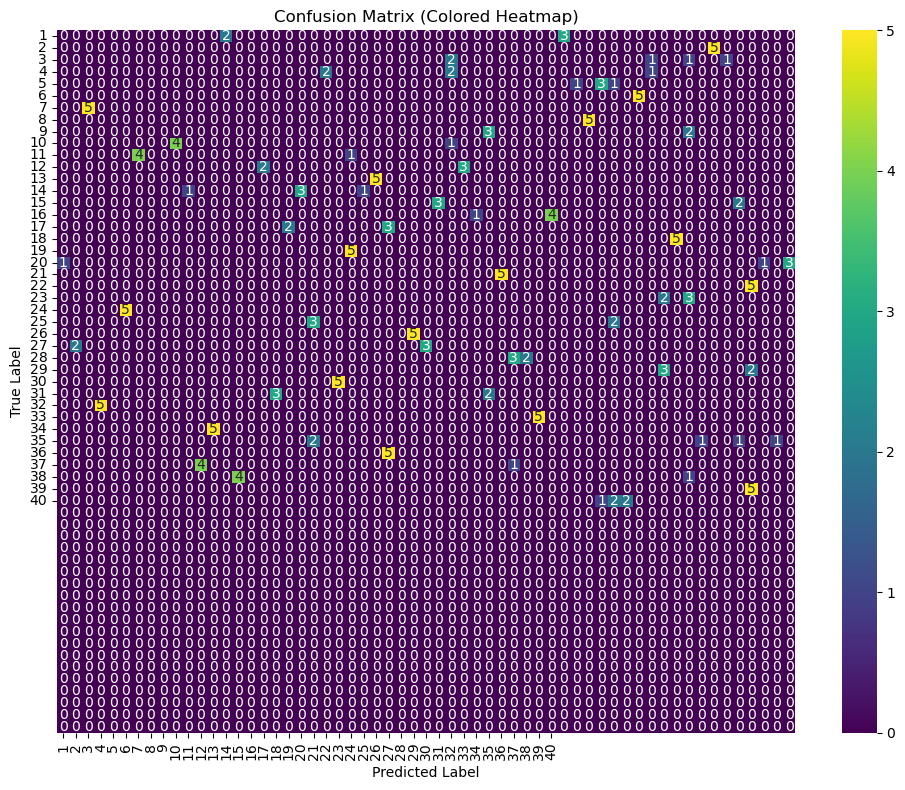

In [14]:
# Find the entry with the highest accuracy
best_alpha, best_K, best_acc = max(results_kmeans, key=lambda x: x[2])

print(f"Best alpha: {best_alpha}, Best K: {best_K}, Accuracy: {best_acc:.4f}")

# Get the PCA eigenvectors for best_alpha
_, eigvecs = pca.project(best_alpha)
mean_face = np.mean(pca.D_train, axis=0)
D_test_centered = pca.D_test - mean_face
test_proj = D_test_centered @ eigvecs

# Fit KMeans on train set (projected)
train_proj, _ = pca.project(best_alpha)
kmeans_best = KMeans(n_clusters=best_K)
kmeans_best.fit(train_proj)

# Predict on test set
y_pred_test = kmeans_best.predict(test_proj)

# Evaluate clustering accuracy
acc = clustering_accuracy(pca.y_test, y_pred_test)
print(f"Test Accuracy: {acc:.4f}")

# F1 and Confusion Matrix
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

f1 = f1_score(pca.y_test, y_pred_test, average='macro')
print(f"Test F1 Score: {f1:.4f}")

# Compute confusion matrix (just to be sure)
cm = confusion_matrix(pca.y_test, y_pred_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', cbar=True, 
            xticklabels=np.unique(pca.y_test), 
            yticklabels=np.unique(pca.y_test))
plt.title("Confusion Matrix (Colored Heatmap)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# print("Confusion Matrix:")
# df = pd.DataFrame(cm)
# print(df.to_string())



### Gaussian Mixture Model Clustering

In [15]:
class GMM:
    def __init__(self, n_components, max_iter=100, tol=1e-3, regularization=1e-6):
        """Class initialization"""
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.regularization = regularization  # for regularization 

    def fit(self, X):
        """Fit the GMM model to the data"""
        np.random.seed(42)
        n_samples, n_features = X.shape

        # initialize parameters
        self.means = X[np.random.choice(n_samples, self.n_components, replace=False)]
        
        self.covariances = np.array([np.cov(X, rowvar=False) + self.regularization*np.eye(n_features)
                                     for _ in range(self.n_components)])
         
        self.weights = np.ones(self.n_components) / self.n_components

        log_likelihood_old = None

        for iteration in range(self.max_iter):
            responsibilities = self._calculate_responsibilities(X)

            # Check log-likelihood for convergence
            log_likelihood = np.sum(np.log(responsibilities.sum(axis=1) + 1e-10))
            if log_likelihood_old is not None and abs(log_likelihood - log_likelihood_old) < self.tol:
                break
            log_likelihood_old = log_likelihood

            self._update_parameters(X, responsibilities)

    def _calculate_responsibilities(self, X):
        n_samples, n_features = X.shape
        responsibilities = np.zeros((n_samples, self.n_components))

        for i in range(self.n_components):
            diff = X - self.means[i]
            cov_reg = self.covariances[i] + self.regularization * np.eye(n_features)
            cov_inv = np.linalg.inv(cov_reg)
            cov_det = np.linalg.det(cov_reg)
            if cov_det <= 0:
                cov_det = 1e-6  # prevent invalid det
            
            norm_const = 1.0 / (np.power(2*np.pi, n_features/2) * np.sqrt(cov_det))
            exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
            responsibilities[:, i] = self.weights[i] * norm_const * np.exp(exponent)

        sum_responsibilities = responsibilities.sum(axis=1, keepdims=True)
        sum_responsibilities[sum_responsibilities == 0] = 1e-10  # prevent division by zero
        responsibilities /= sum_responsibilities
        
        return responsibilities

    def _update_parameters(self, X, responsibilities):
        n_samples, n_features = X.shape
        weights = responsibilities.sum(axis=0)

        # Avoid division by zero
        weights[weights == 0] = 1e-10

        self.means = (responsibilities.T @ X) / weights[:, np.newaxis]

        for i in range(self.n_components):
            diff = X - self.means[i]
            weighted_diff = responsibilities[:, i][:, np.newaxis] * diff
            cov_matrix = weighted_diff.T @ diff / weights[i]
            self.covariances[i] = cov_matrix + self.regularization * np.eye(n_features)

        self.weights = weights / n_samples


    def predict(self, X):
        """Predict the closest cluster each sample belongs to"""
        responsibilities = self._calculate_responsibilities(X)
        return np.argmax(responsibilities, axis=1)

### GMM Clustering Evaluation

In [16]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import f1_score, confusion_matrix

def gmm_clustering_accuracy(y_true, y_pred):
    """Compute clustering accuracy using the Hungarian algorithm"""
    D = max(y_true.max(), y_pred.max()) + 1
    cost_matrix = np.zeros((D, D), dtype=np.int64)

    for i in range(len(y_true)):
        cost_matrix[y_pred[i], y_true[i]] += 1

    row_ind, col_ind = linear_sum_assignment(cost_matrix.max() - cost_matrix)
    total_correct = sum(cost_matrix[i, j] for i, j in zip(row_ind, col_ind))

    return total_correct / len(y_true)


### Run GMM for different alpha and K

In [17]:
# Normalize the data
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
D_train_scaled = scaler.fit_transform(D_train)
D_test_scaled = scaler.transform(D_test)

# np.random.seed(42)  

results_gmm = []
for alpha in [0.8, 0.85, 0.9, 0.95]:
    pca_instance = PCA(D_train_scaled, D_test_scaled, y_train, y_test)
    reduced_data, eigvecs = pca_instance.project(alpha)
    
    for K in [20, 40, 60]:
        gmm = GMM(n_components=K)
        gmm.fit(reduced_data)
        y_pred = gmm.predict(reduced_data)
        acc = gmm_clustering_accuracy(y_train, y_pred)
        results_gmm.append((alpha, K, acc))
        print(f"Alpha: {alpha}, K: {K}, Accuracy: {acc:.4f}")
    print("--------------------------------------")


Alpha: 0.8, K: 20, Accuracy: 0.3250
Alpha: 0.8, K: 40, Accuracy: 0.5100
Alpha: 0.8, K: 60, Accuracy: 0.5900
--------------------------------------
Alpha: 0.85, K: 20, Accuracy: 0.2800
Alpha: 0.85, K: 40, Accuracy: 0.4800
Alpha: 0.85, K: 60, Accuracy: 0.5550
--------------------------------------
Alpha: 0.9, K: 20, Accuracy: 0.2250
Alpha: 0.9, K: 40, Accuracy: 0.3750
Alpha: 0.9, K: 60, Accuracy: 0.4600
--------------------------------------
Alpha: 0.95, K: 20, Accuracy: 0.1600
Alpha: 0.95, K: 40, Accuracy: 0.2700
Alpha: 0.95, K: 60, Accuracy: 0.3400
--------------------------------------


### Plot Accuracy vs K and Alpha (GMM)

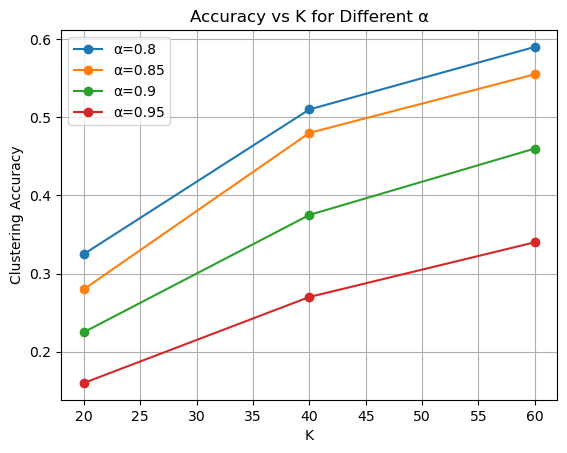

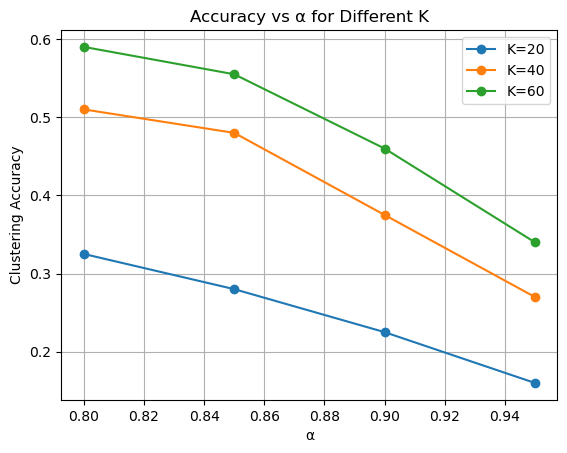

In [18]:
for alpha in [0.8, 0.85, 0.9, 0.95]:
    accs = [acc for a, k, acc in results_gmm if a == alpha]
    ks = [k for a, k, acc in results_gmm if a == alpha]
    plt.plot(ks, accs, marker='o', label=f'α={alpha}')

plt.xlabel('K')
plt.ylabel('Clustering Accuracy')
plt.title('Accuracy vs K for Different α')
plt.legend()
plt.grid()
plt.show()

for k in [20, 40, 60]:
    accs = [acc for a, k_val, acc in results_gmm if k_val == k]
    alphas = [a for a, k_val, acc in results_gmm if k_val == k]
    plt.plot(alphas, accs, marker='o', label=f'K={k}')
    
plt.xlabel('α')
plt.ylabel('Clustering Accuracy')
plt.title('Accuracy vs α for Different K')
plt.legend()
plt.grid()
plt.show()

### Evaluate Best GMM Model on the Test Set

Best alpha: 0.8, Best K: 60, Accuracy: 0.5900
Test Accuracy: 0.1050
Test F1 Score: 0.0059


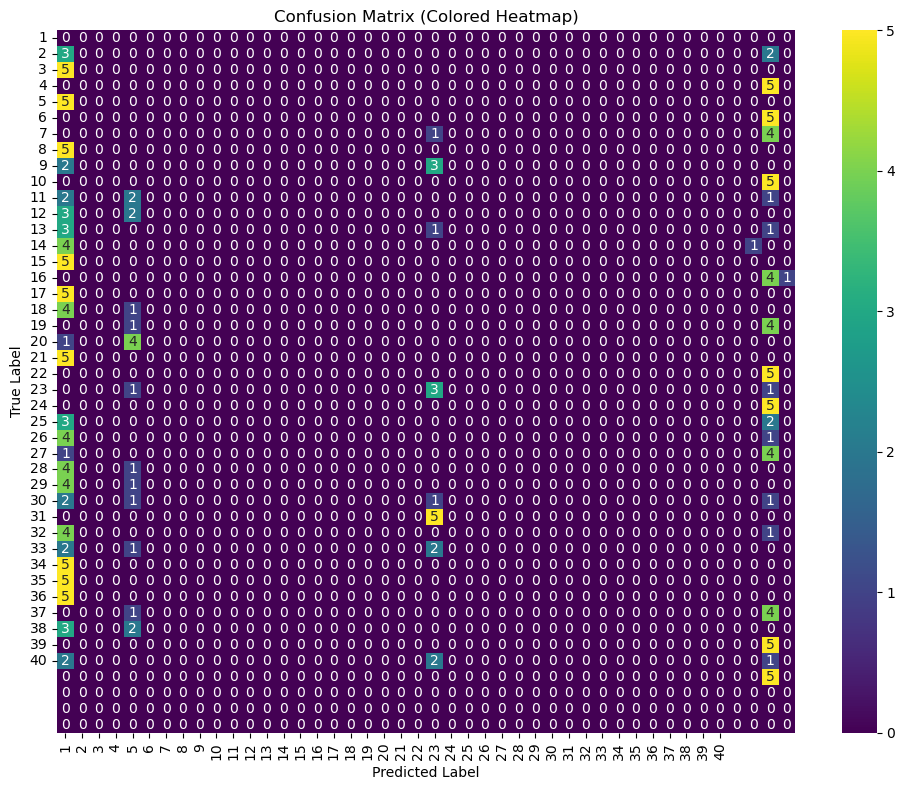

In [19]:
from sklearn.mixture import GaussianMixture

# best alpha, K, and accuracy
best_alpha, best_K, best_acc = max(results_gmm, key=lambda x: x[2])
print(f"Best alpha: {best_alpha}, Best K: {best_K}, Accuracy: {best_acc:.4f}")


# PCA eigenvectors for best_alpha
_, eigvecs = pca.project(best_alpha)
mean_face = np.mean(pca.D_train, axis=0)
D_test_centered = pca.D_test - mean_face
test_proj = D_test_centered @ eigvecs

# fit the best GMM model on the train set
train_proj, _ = pca.project(best_alpha)
gmm_best = GMM(n_components=best_K)
gmm_best.fit(train_proj)

y_pred_test = gmm_best.predict(test_proj)

# clustering accuracy 
acc = gmm_clustering_accuracy(pca.y_test, y_pred_test)
print(f"Test Accuracy: {acc:.4f}")

# F1 Score 
f1 = f1_score(pca.y_test, y_pred_test, average='macro')
print(f"Test F1 Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(pca.y_test, y_pred_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', cbar=True, 
            xticklabels=np.unique(pca.y_test), 
            yticklabels=np.unique(pca.y_test))
plt.title("Confusion Matrix (Colored Heatmap)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# print("Confusion Matrix:")
# df = pd.DataFrame(cm)
# print(df.to_string())

### Bonus (Autoencoders)

In [507]:
import numpy as np

class Autoencoder:
    def __init__(self, input_dim, hidden_dim):
        # Xavier initialization chooses initial weights smartly so they are not too small or too big
        # Used in encoding 
        limit1 = np.sqrt(6 / (input_dim + hidden_dim))
        self.W1 = np.random.uniform(-limit1, limit1, (hidden_dim, input_dim))   
        self.b1 = np.zeros((hidden_dim,))

        # Used in decoding 
        limit2 = np.sqrt(6 / (hidden_dim + input_dim))
        self.W2 = np.random.uniform(-limit2, limit2, (input_dim, hidden_dim))
        self.b2 = np.zeros((input_dim,))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_deriv(self, x):
        s = self.sigmoid(x)
        return s * (1 - s)

    def encode(self, X):
        self.Z1 = X @ self.W1.T + self.b1  # Pre-activation
        self.A1 = self.sigmoid(self.Z1)    # Activation
        return self.A1

    def decode(self, A1):
        self.Z2 = A1 @ self.W2.T + self.b2
        self.A2 = self.sigmoid(self.Z2)
        return self.A2

    def forward(self, X):
        return self.decode(self.encode(X))

    def compute_loss(self, X, X_hat):
        return np.mean((X - X_hat) ** 2)

    def train(self, X, lr, epochs):
        losses = []
        for epoch in range(epochs):
            # Forward pass
            A1 = self.encode(X)
            A2 = self.decode(A1)
            loss = self.compute_loss(X, A2)

            # Backpropagation
            dA2 = 2 * (A2 - X) / X.shape[0]  # MSE derivative
            dZ2 = dA2 * self.sigmoid_deriv(self.Z2)     # dL/dZ2
            dW2 = dZ2.T @ A1        # dL/dW2
            db2 = np.sum(dZ2, axis=0)       # dL/db2

            dA1 = dZ2 @ self.W2     # dL/dA1
            dZ1 = dA1 * self.sigmoid_deriv(self.Z1)     # dL/dZ1
            dW1 = dZ1.T @ X     # dL/dW1
            db1 = np.sum(dZ1, axis=0)     # dL/db1

            # Update weights
            self.W1 -= lr * dW1
            self.b1 -= lr * db1
            self.W2 -= lr * dW2
            self.b2 -= lr * db2

            losses.append(loss)
            if epoch % 20 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.5f}, lr: {lr}")
        
        plt.plot(losses)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Curve")
        plt.show()
        return losses
    
    
    def visualize_reconstruction(self, X_original, index, image_shape=(112, 92)):
        
        original = X_original[index]
        # Reshape before encoding to make it [1, 10304] instead of [10304,]
        encoded = self.encode(original.reshape(1, -1))
        # Returns it to 1D [10304, ] instead of [1, 10304] after decoding
        decoded = self.decode(encoded).reshape(-1)

        fig, axs = plt.subplots(1, 2, figsize=(8, 4))

        axs[0].imshow(original.reshape(image_shape), cmap='gray')
        axs[0].set_title("Original")
        axs[0].axis('off')

        axs[1].imshow(decoded.reshape(image_shape), cmap='gray')
        axs[1].set_title("Reconstruction")
        axs[1].axis('off')

        plt.suptitle(f"Autoencoder Reconstruction (sample #{index})")
        plt.show()




### Autoencoder Training

Epoch 0, Loss: 0.05033, lr: 0.05
Epoch 20, Loss: 0.02331, lr: 0.05
Epoch 40, Loss: 0.02166, lr: 0.05
Epoch 60, Loss: 0.02146, lr: 0.05
Epoch 80, Loss: 0.02029, lr: 0.05


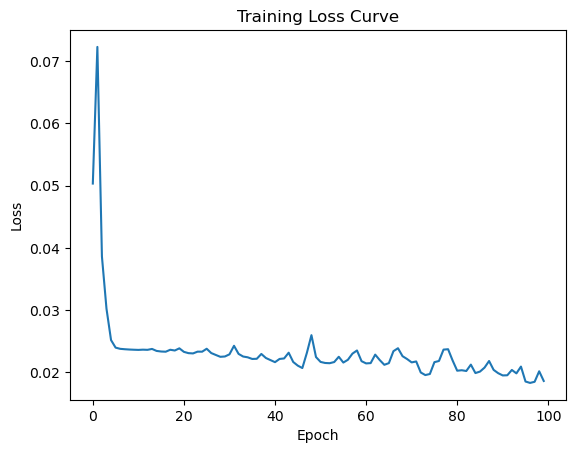

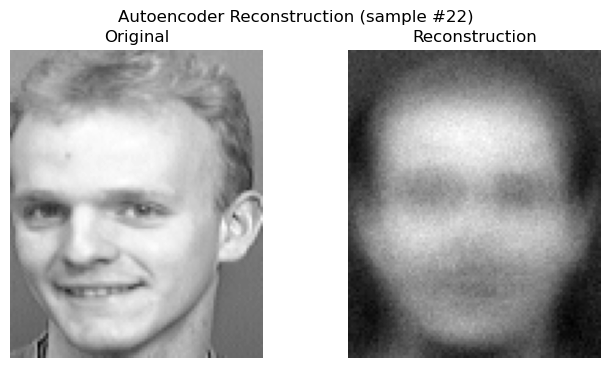

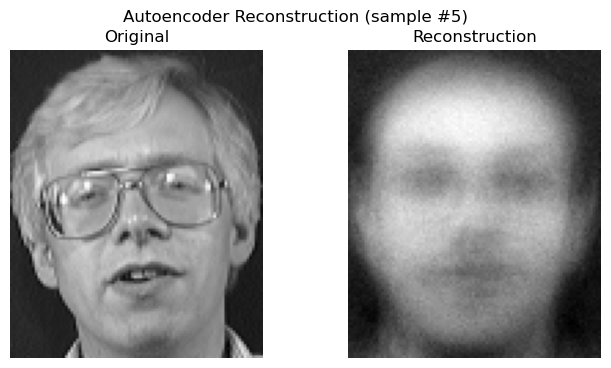

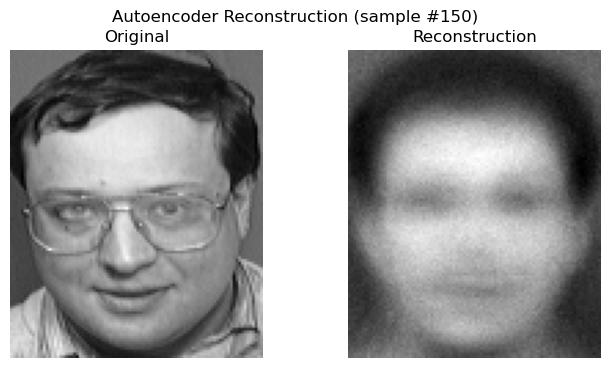

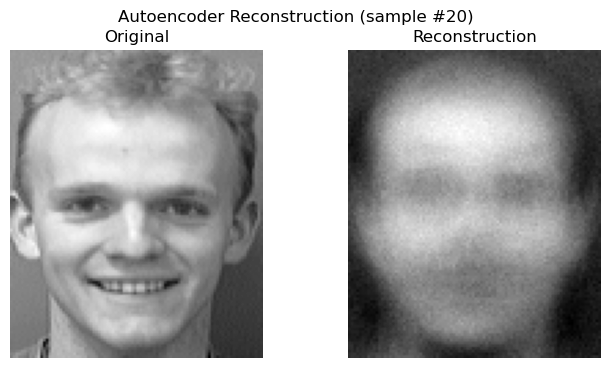

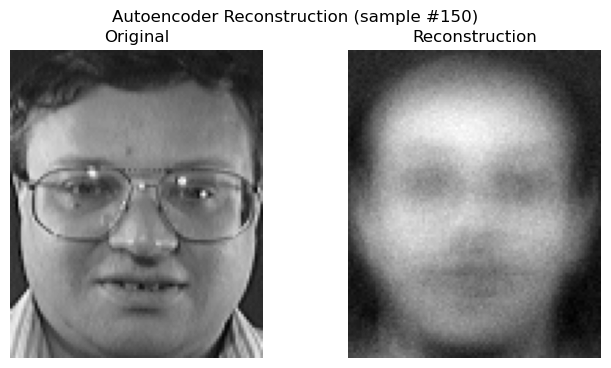

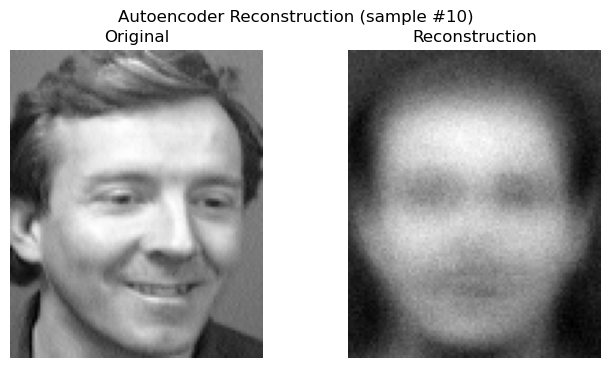

In [508]:
# Normalize
D_train_norm = D_train / 255.0
D_test_norm = D_test / 255.0


# Initialize
auto = Autoencoder(input_dim=10304, hidden_dim=4000)
# Train
auto.train(D_train_norm, lr=0.05, epochs=100)
# Visualize
auto.visualize_reconstruction(D_train_norm, index=22)
auto.visualize_reconstruction(D_train_norm, index=5)
auto.visualize_reconstruction(D_train_norm, index=150)

#Test data set

# Visualize
auto.visualize_reconstruction(D_test_norm, index=20)
auto.visualize_reconstruction(D_test_norm, index=150)
auto.visualize_reconstruction(D_test_norm, index=10)


# Train Autoencoder with different hyperparameters
hidden_dims = [50, 100, 200]
learning_rates = [0.01, 0.05, 0.1]
epochs_list = [50, 100, 200]  # Different number of epochs to try
# 
# for hidden_dim in hidden_dims:
#     for lr in learning_rates:
#         for epochs in epochs_list:
#             print(f"\nTraining Autoencoder: hidden_dim={hidden_dim}, lr={lr}, epochs={epochs}")
# 
#             # Initialize
#             auto = Autoencoder(input_dim=10304, hidden_dim=hidden_dim)
#             # Train
#             auto.train(D_train_norm, lr=lr, epochs=epochs)
#             # Visualize
#             auto.visualize_reconstruction(D_train_norm, index=22)
#             auto.visualize_reconstruction(D_train_norm, index=5)
#             auto.visualize_reconstruction(D_train_norm, index=150)
# 
#             encoded_features = auto.encode(D_train_norm)  


### K-Means on Encoded Data for Autoencoders


Training Autoencoder: hidden_dim=100, lr=0.05, epochs=100, K=20
Epoch 0, Loss: 0.04216, lr: 0.05
Epoch 20, Loss: 0.02385, lr: 0.05
Epoch 40, Loss: 0.02374, lr: 0.05
Epoch 60, Loss: 0.02342, lr: 0.05
Epoch 80, Loss: 0.02270, lr: 0.05


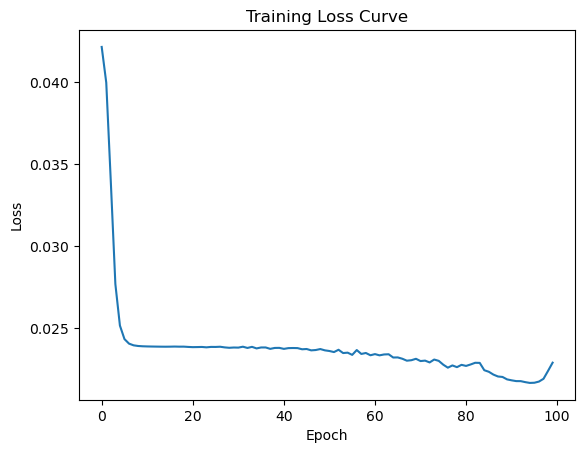

Hidden Dim: 100, Learning Rate: 0.05, Epochs: 100, K: 20, Accuracy: 0.3350
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=100, lr=0.05, epochs=100, K=40
Epoch 0, Loss: 0.04197, lr: 0.05
Epoch 20, Loss: 0.02383, lr: 0.05
Epoch 40, Loss: 0.02367, lr: 0.05
Epoch 60, Loss: 0.02296, lr: 0.05
Epoch 80, Loss: 0.02207, lr: 0.05


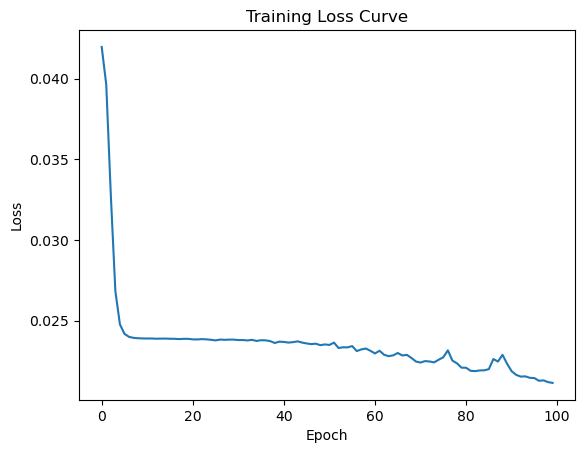

Hidden Dim: 100, Learning Rate: 0.05, Epochs: 100, K: 40, Accuracy: 0.4300
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=100, lr=0.05, epochs=100, K=60
Epoch 0, Loss: 0.04197, lr: 0.05
Epoch 20, Loss: 0.02383, lr: 0.05
Epoch 40, Loss: 0.02367, lr: 0.05
Epoch 60, Loss: 0.02296, lr: 0.05
Epoch 80, Loss: 0.02207, lr: 0.05


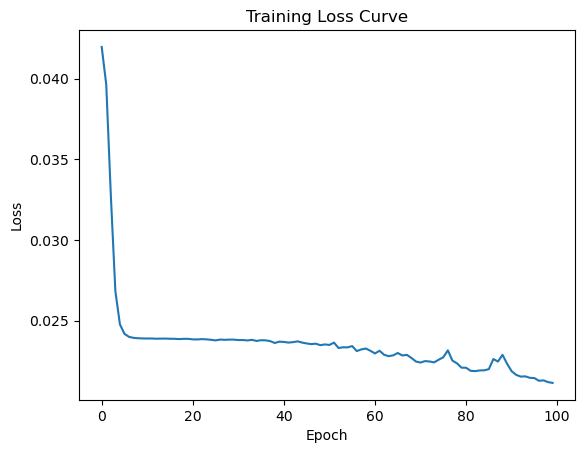

Hidden Dim: 100, Learning Rate: 0.05, Epochs: 100, K: 60, Accuracy: 0.4650
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=100, lr=0.1, epochs=100, K=20
Epoch 0, Loss: 0.04197, lr: 0.1
Epoch 20, Loss: 0.02389, lr: 0.1
Epoch 40, Loss: 0.02390, lr: 0.1
Epoch 60, Loss: 0.02390, lr: 0.1
Epoch 80, Loss: 0.02389, lr: 0.1


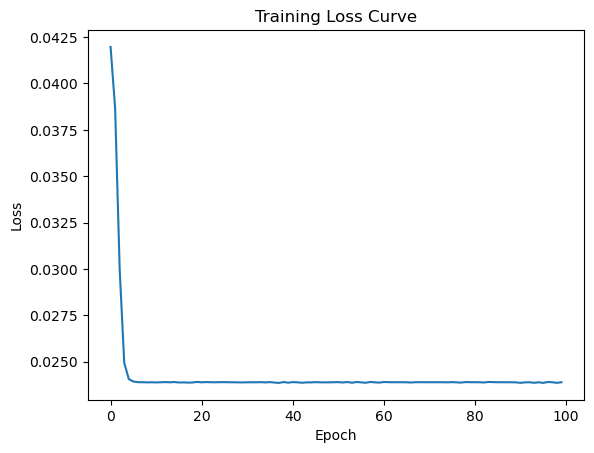

Hidden Dim: 100, Learning Rate: 0.1, Epochs: 100, K: 20, Accuracy: 0.2650
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=100, lr=0.1, epochs=100, K=40
Epoch 0, Loss: 0.04197, lr: 0.1
Epoch 20, Loss: 0.02389, lr: 0.1
Epoch 40, Loss: 0.02390, lr: 0.1
Epoch 60, Loss: 0.02390, lr: 0.1
Epoch 80, Loss: 0.02389, lr: 0.1


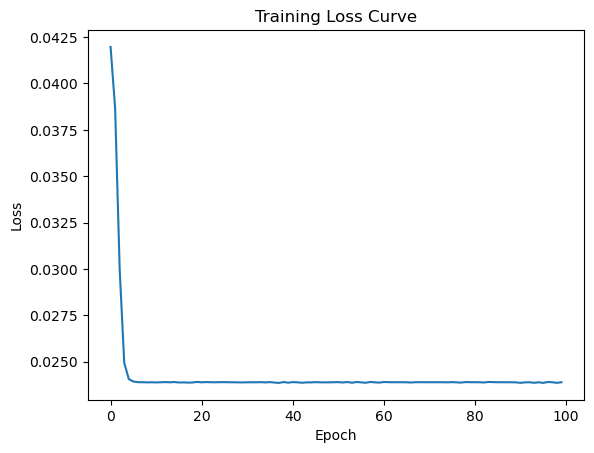

Hidden Dim: 100, Learning Rate: 0.1, Epochs: 100, K: 40, Accuracy: 0.3900
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=100, lr=0.1, epochs=100, K=60
Epoch 0, Loss: 0.04197, lr: 0.1
Epoch 20, Loss: 0.02389, lr: 0.1
Epoch 40, Loss: 0.02390, lr: 0.1
Epoch 60, Loss: 0.02390, lr: 0.1
Epoch 80, Loss: 0.02389, lr: 0.1


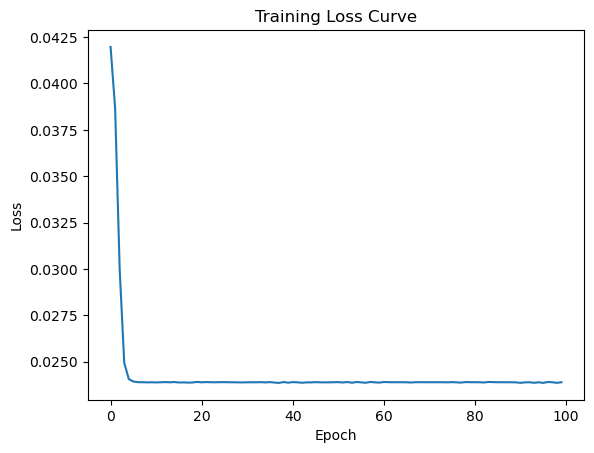

Hidden Dim: 100, Learning Rate: 0.1, Epochs: 100, K: 60, Accuracy: 0.3850
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=200, lr=0.05, epochs=100, K=20
Epoch 0, Loss: 0.04237, lr: 0.05
Epoch 20, Loss: 0.02378, lr: 0.05
Epoch 40, Loss: 0.02304, lr: 0.05
Epoch 60, Loss: 0.02252, lr: 0.05
Epoch 80, Loss: 0.02081, lr: 0.05


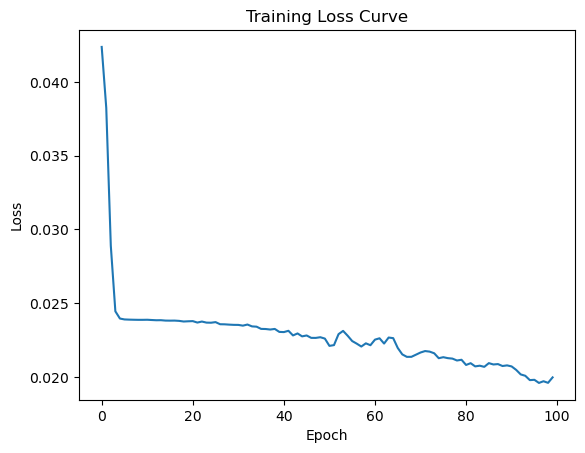

Hidden Dim: 200, Learning Rate: 0.05, Epochs: 100, K: 20, Accuracy: 0.3750
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=200, lr=0.05, epochs=100, K=40
Epoch 0, Loss: 0.04237, lr: 0.05
Epoch 20, Loss: 0.02378, lr: 0.05
Epoch 40, Loss: 0.02304, lr: 0.05
Epoch 60, Loss: 0.02252, lr: 0.05
Epoch 80, Loss: 0.02081, lr: 0.05


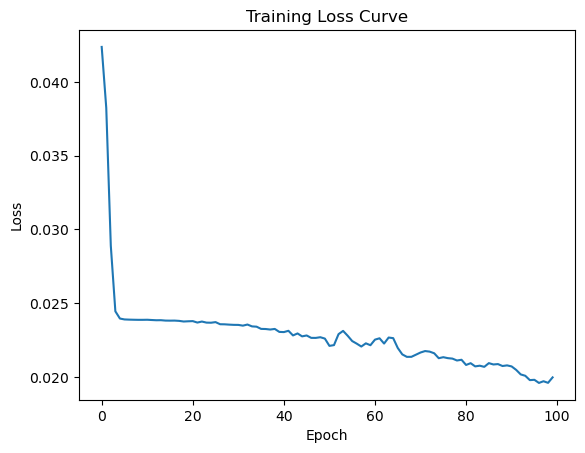

Hidden Dim: 200, Learning Rate: 0.05, Epochs: 100, K: 40, Accuracy: 0.4800
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=200, lr=0.05, epochs=100, K=60
Epoch 0, Loss: 0.04237, lr: 0.05
Epoch 20, Loss: 0.02378, lr: 0.05
Epoch 40, Loss: 0.02304, lr: 0.05
Epoch 60, Loss: 0.02252, lr: 0.05
Epoch 80, Loss: 0.02081, lr: 0.05


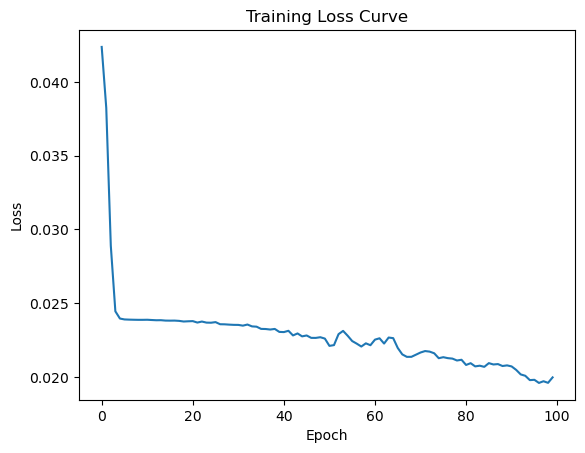

Hidden Dim: 200, Learning Rate: 0.05, Epochs: 100, K: 60, Accuracy: 0.4800
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=200, lr=0.1, epochs=100, K=20
Epoch 0, Loss: 0.04237, lr: 0.1
Epoch 20, Loss: 0.02389, lr: 0.1
Epoch 40, Loss: 0.02389, lr: 0.1
Epoch 60, Loss: 0.02391, lr: 0.1
Epoch 80, Loss: 0.02391, lr: 0.1


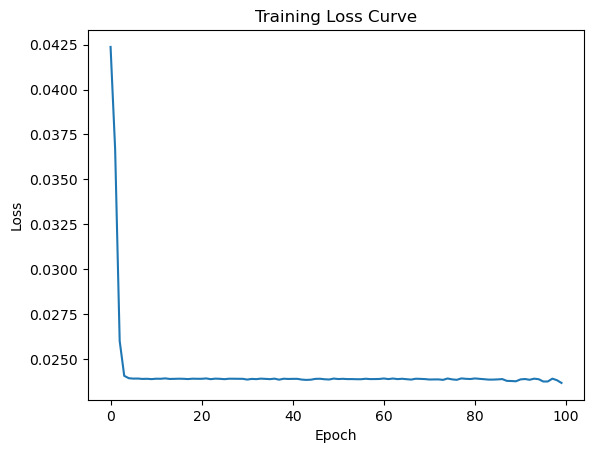

Hidden Dim: 200, Learning Rate: 0.1, Epochs: 100, K: 20, Accuracy: 0.2700
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=200, lr=0.1, epochs=100, K=40
Epoch 0, Loss: 0.04237, lr: 0.1
Epoch 20, Loss: 0.02389, lr: 0.1
Epoch 40, Loss: 0.02389, lr: 0.1
Epoch 60, Loss: 0.02391, lr: 0.1
Epoch 80, Loss: 0.02391, lr: 0.1


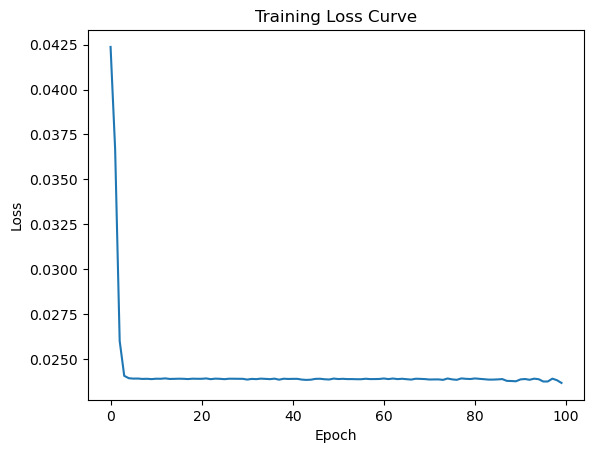

Hidden Dim: 200, Learning Rate: 0.1, Epochs: 100, K: 40, Accuracy: 0.3400
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=200, lr=0.1, epochs=100, K=60
Epoch 0, Loss: 0.04237, lr: 0.1
Epoch 20, Loss: 0.02389, lr: 0.1
Epoch 40, Loss: 0.02389, lr: 0.1
Epoch 60, Loss: 0.02391, lr: 0.1
Epoch 80, Loss: 0.02391, lr: 0.1


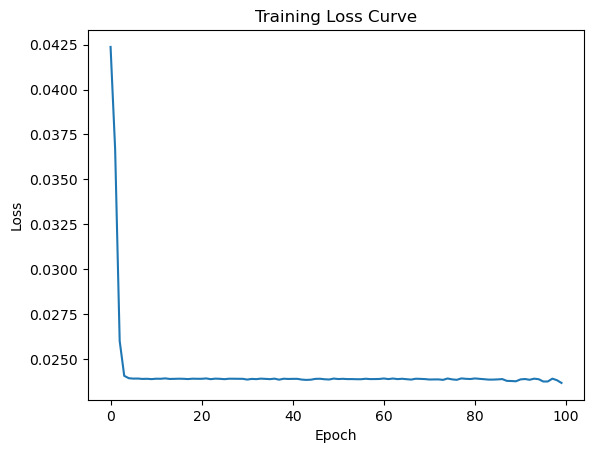

Hidden Dim: 200, Learning Rate: 0.1, Epochs: 100, K: 60, Accuracy: 0.3650
------------------------------------------------------------------------------------------


In [509]:
# Initialize the Autoencoder
autoencoder = Autoencoder(input_dim=10304, hidden_dim=200)

# Encode the data
D_train_encoded = autoencoder.encode(D_train_norm)
D_test_encoded = autoencoder.encode(D_test_norm)

# KMeans clustering on encoded data
results_kmeans_autoencoder = []
for dim in [100, 200]:
    for lr in [0.05, 0.1]:
        for epochs in [100]:
            for K in [20, 40, 60]:
                print(f"\nTraining Autoencoder: hidden_dim={dim}, lr={lr}, epochs={epochs}, K={K}")

                # Initialize
                auto = Autoencoder(input_dim=10304, hidden_dim=dim)
                # Train
                auto.train(D_train_norm, lr=lr, epochs=epochs)
                # Encode the data
                D_train_encoded = auto.encode(D_train_norm)

                # Fit KMeans
                kmeans = KMeans(n_clusters=K)
                kmeans.fit(D_train_encoded)

                acc = clustering_accuracy(y_train, kmeans.labels_)
                results_kmeans_autoencoder.append((dim, lr, epochs, K, acc))
                print(f"Hidden Dim: {dim}, Learning Rate: {lr}, Epochs: {epochs}, K: {K}, Accuracy: {acc:.4f}")
                print("------------------------------------------------------------------------------------------")

### Plot Accuracy vs K for Autoencoder (K-Means)

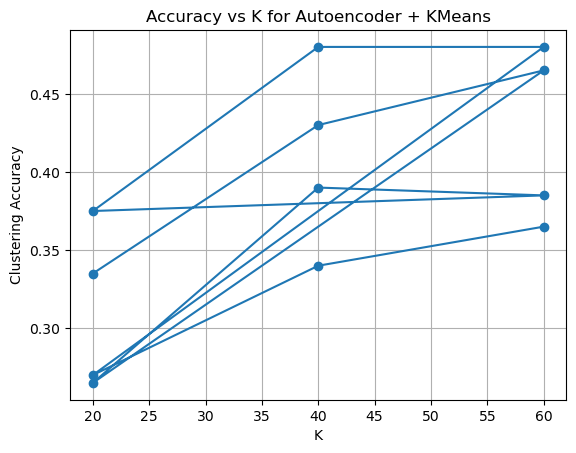

In [510]:
ks = [k for _, _, _, k, acc in results_kmeans_autoencoder]
accs = [acc for _, _, _, k, acc in results_kmeans_autoencoder]

plt.plot(ks, accs, marker='o')
plt.xlabel('K')
plt.ylabel('Clustering Accuracy')
plt.title('Accuracy vs K for Autoencoder + KMeans')
plt.grid()
plt.show()

### Evaluate Best K-Means on Test Set for Autoencoder

Best K: 60, Accuracy: 0.4800, Hidden Dim: 100, Learning Rate: 0.05, Epochs: 40
Test Accuracy: 0.0700
Test F1 Score: 0.0077


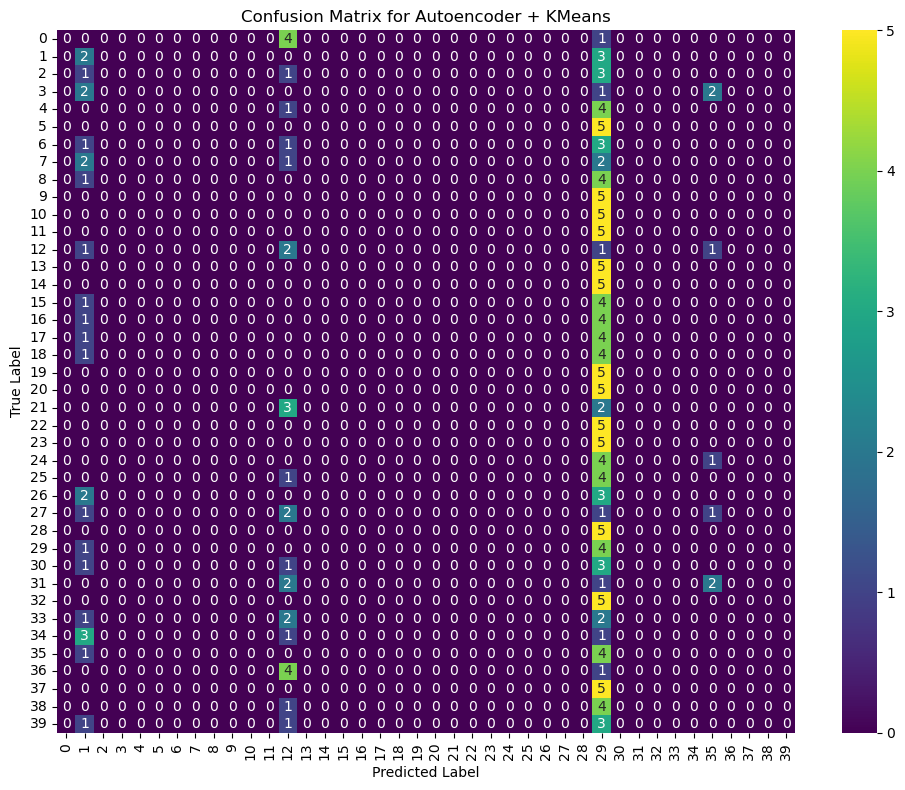

In [511]:
best_dim, best_lr, best_dim, best_epochs, best_acc = max(results_kmeans_autoencoder, key=lambda x: x[4])
print(f"Best K: {best_K}, Accuracy: {best_acc:.4f}, Hidden Dim: {best_dim}, Learning Rate: {best_lr}, Epochs: {best_epochs}")

# Train best KMeans again
kmeans_best = KMeans(n_clusters=best_K)
kmeans_best.fit(D_train_encoded)

# Predict on encoded test set
y_pred_test = kmeans_best.predict(D_test_encoded)

# Evaluate
acc = clustering_accuracy(y_test, y_pred_test)
print(f"Test Accuracy: {acc:.4f}")

# F1 Score
f1 = f1_score(y_test, y_pred_test, average='macro')
print(f"Test F1 Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', cbar=True)
plt.title('Confusion Matrix for Autoencoder + KMeans')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


### GMM on Encoded Data for Autoencoders


Training Autoencoder: hidden_dim=100, lr=0.05, epochs=100, K=20
Epoch 0, Loss: 0.04194, lr: 0.05
Epoch 20, Loss: 0.02387, lr: 0.05
Epoch 40, Loss: 0.02378, lr: 0.05
Epoch 60, Loss: 0.02365, lr: 0.05
Epoch 80, Loss: 0.02318, lr: 0.05


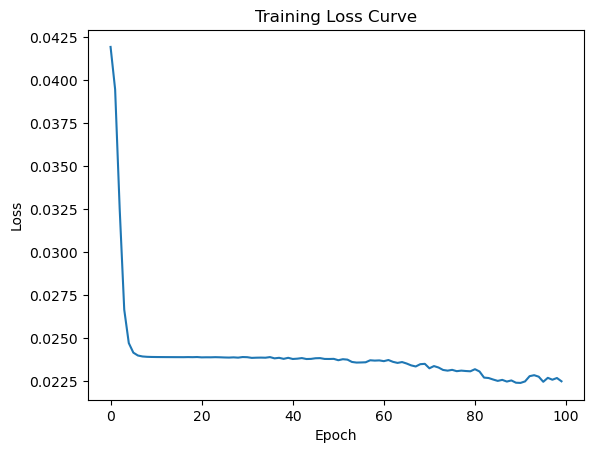

Hidden Dim: 100, Learning Rate: 0.05, Epochs: 100, K: 20, Accuracy: 0.2850
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=100, lr=0.05, epochs=100, K=40
Epoch 0, Loss: 0.04197, lr: 0.05
Epoch 20, Loss: 0.02383, lr: 0.05
Epoch 40, Loss: 0.02367, lr: 0.05
Epoch 60, Loss: 0.02296, lr: 0.05
Epoch 80, Loss: 0.02207, lr: 0.05


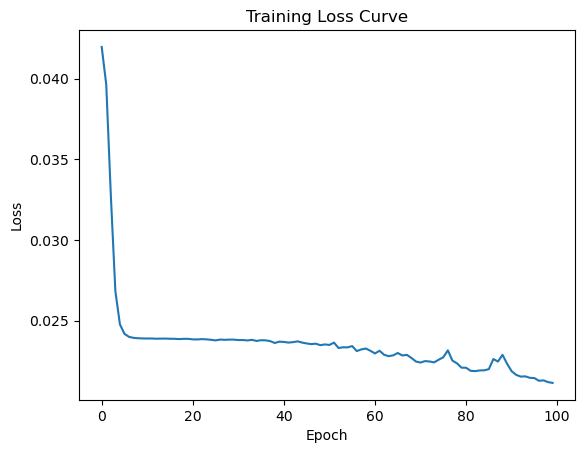

Hidden Dim: 100, Learning Rate: 0.05, Epochs: 100, K: 40, Accuracy: 0.4000
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=100, lr=0.05, epochs=100, K=60
Epoch 0, Loss: 0.04197, lr: 0.05
Epoch 20, Loss: 0.02383, lr: 0.05
Epoch 40, Loss: 0.02367, lr: 0.05
Epoch 60, Loss: 0.02296, lr: 0.05
Epoch 80, Loss: 0.02207, lr: 0.05


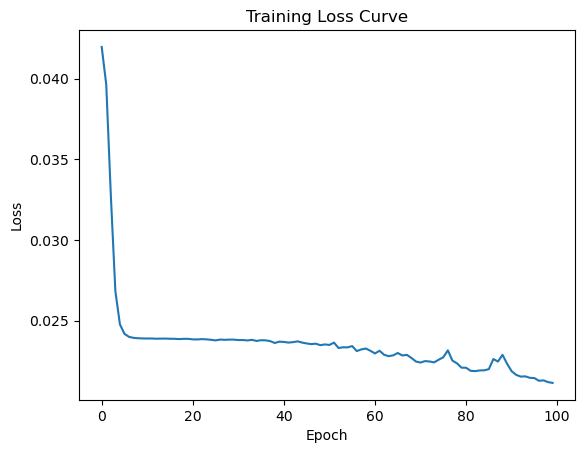

Hidden Dim: 100, Learning Rate: 0.05, Epochs: 100, K: 60, Accuracy: 0.4550
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=100, lr=0.1, epochs=100, K=20
Epoch 0, Loss: 0.04197, lr: 0.1
Epoch 20, Loss: 0.02389, lr: 0.1
Epoch 40, Loss: 0.02390, lr: 0.1
Epoch 60, Loss: 0.02390, lr: 0.1
Epoch 80, Loss: 0.02389, lr: 0.1


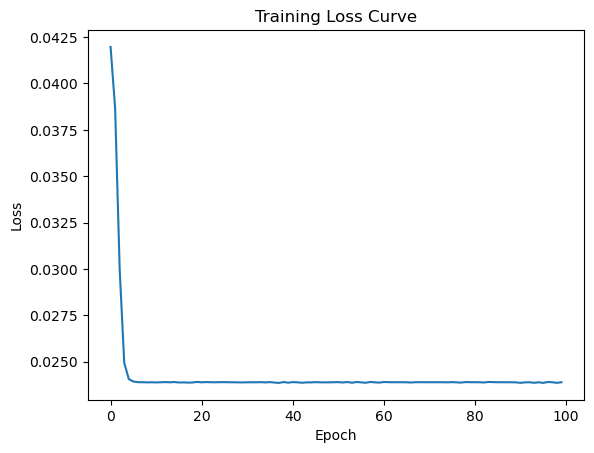

Hidden Dim: 100, Learning Rate: 0.1, Epochs: 100, K: 20, Accuracy: 0.2150
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=100, lr=0.1, epochs=100, K=40
Epoch 0, Loss: 0.04197, lr: 0.1
Epoch 20, Loss: 0.02389, lr: 0.1
Epoch 40, Loss: 0.02390, lr: 0.1
Epoch 60, Loss: 0.02390, lr: 0.1
Epoch 80, Loss: 0.02389, lr: 0.1


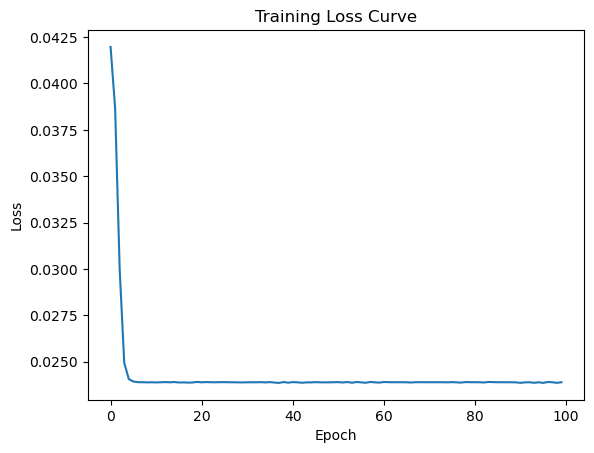

Hidden Dim: 100, Learning Rate: 0.1, Epochs: 100, K: 40, Accuracy: 0.1900
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=100, lr=0.1, epochs=100, K=60
Epoch 0, Loss: 0.04197, lr: 0.1
Epoch 20, Loss: 0.02389, lr: 0.1
Epoch 40, Loss: 0.02390, lr: 0.1
Epoch 60, Loss: 0.02390, lr: 0.1
Epoch 80, Loss: 0.02389, lr: 0.1


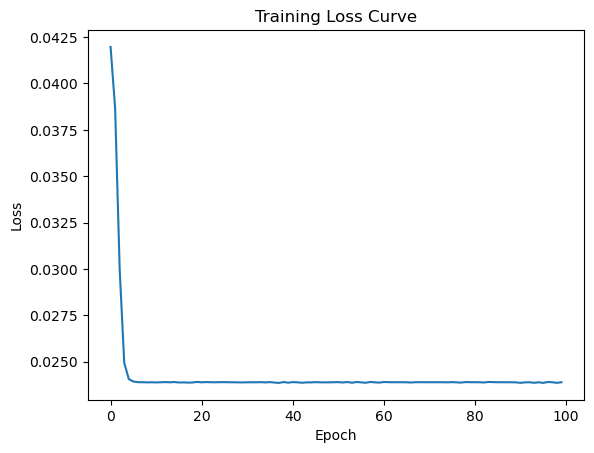

Hidden Dim: 100, Learning Rate: 0.1, Epochs: 100, K: 60, Accuracy: 0.2250
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=200, lr=0.05, epochs=100, K=20
Epoch 0, Loss: 0.04237, lr: 0.05
Epoch 20, Loss: 0.02378, lr: 0.05
Epoch 40, Loss: 0.02304, lr: 0.05
Epoch 60, Loss: 0.02252, lr: 0.05
Epoch 80, Loss: 0.02081, lr: 0.05


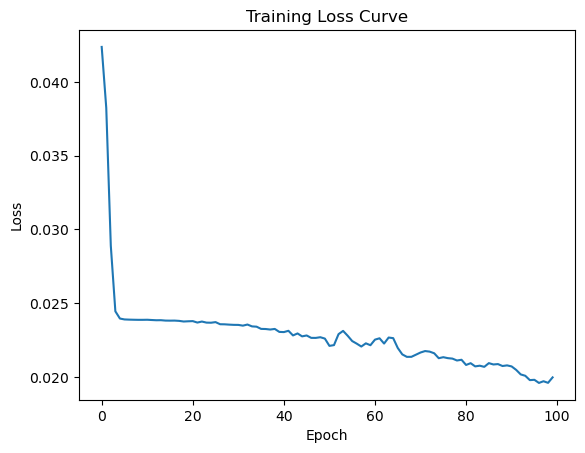

Hidden Dim: 200, Learning Rate: 0.05, Epochs: 100, K: 20, Accuracy: 0.1850
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=200, lr=0.05, epochs=100, K=40
Epoch 0, Loss: 0.04237, lr: 0.05
Epoch 20, Loss: 0.02378, lr: 0.05
Epoch 40, Loss: 0.02304, lr: 0.05
Epoch 60, Loss: 0.02252, lr: 0.05
Epoch 80, Loss: 0.02081, lr: 0.05


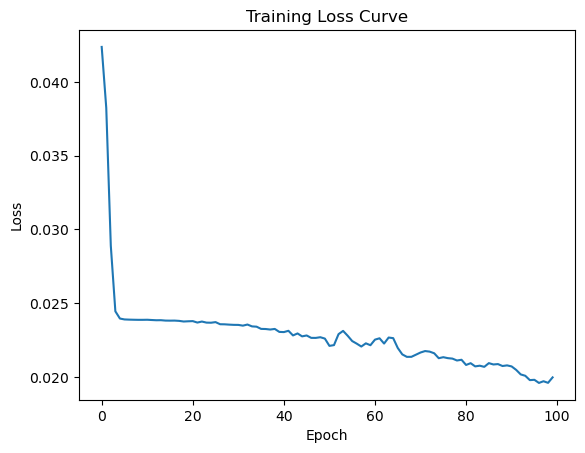

Hidden Dim: 200, Learning Rate: 0.05, Epochs: 100, K: 40, Accuracy: 0.3350
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=200, lr=0.05, epochs=100, K=60
Epoch 0, Loss: 0.04237, lr: 0.05
Epoch 20, Loss: 0.02378, lr: 0.05
Epoch 40, Loss: 0.02304, lr: 0.05
Epoch 60, Loss: 0.02252, lr: 0.05
Epoch 80, Loss: 0.02081, lr: 0.05


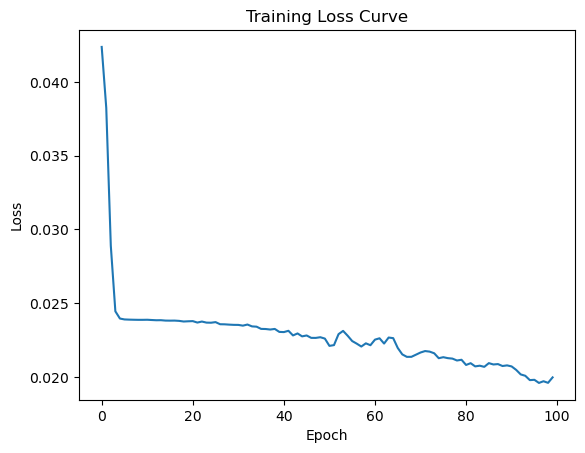

Hidden Dim: 200, Learning Rate: 0.05, Epochs: 100, K: 60, Accuracy: 0.4300
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=200, lr=0.1, epochs=100, K=20
Epoch 0, Loss: 0.04237, lr: 0.1
Epoch 20, Loss: 0.02389, lr: 0.1
Epoch 40, Loss: 0.02389, lr: 0.1
Epoch 60, Loss: 0.02391, lr: 0.1
Epoch 80, Loss: 0.02391, lr: 0.1


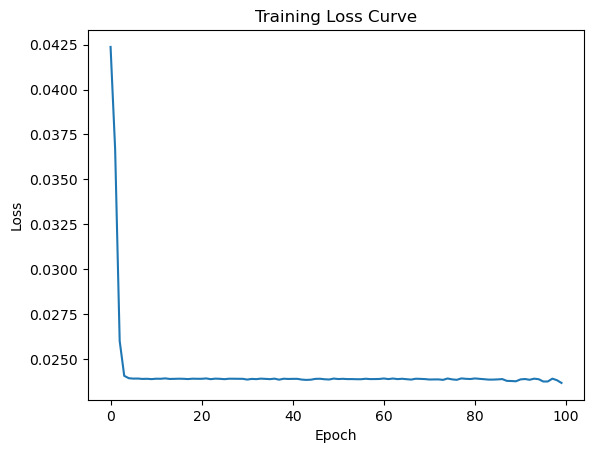

Hidden Dim: 200, Learning Rate: 0.1, Epochs: 100, K: 20, Accuracy: 0.2650
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=200, lr=0.1, epochs=100, K=40
Epoch 0, Loss: 0.04237, lr: 0.1
Epoch 20, Loss: 0.02389, lr: 0.1
Epoch 40, Loss: 0.02389, lr: 0.1
Epoch 60, Loss: 0.02391, lr: 0.1
Epoch 80, Loss: 0.02391, lr: 0.1


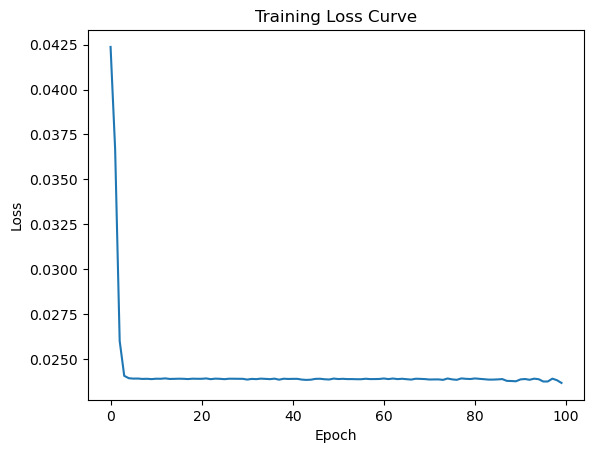

Hidden Dim: 200, Learning Rate: 0.1, Epochs: 100, K: 40, Accuracy: 0.4050
------------------------------------------------------------------------------------------

Training Autoencoder: hidden_dim=200, lr=0.1, epochs=100, K=60
Epoch 0, Loss: 0.04237, lr: 0.1
Epoch 20, Loss: 0.02389, lr: 0.1
Epoch 40, Loss: 0.02389, lr: 0.1
Epoch 60, Loss: 0.02391, lr: 0.1
Epoch 80, Loss: 0.02391, lr: 0.1


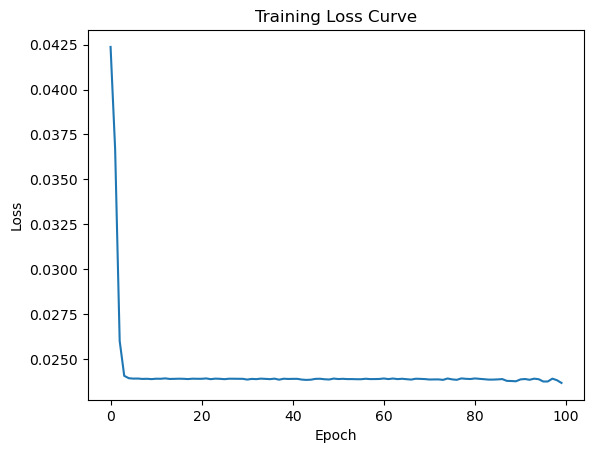

Hidden Dim: 200, Learning Rate: 0.1, Epochs: 100, K: 60, Accuracy: 0.4300
------------------------------------------------------------------------------------------


In [512]:
# Initialize the Autoencoder
autoencoder = Autoencoder(input_dim=10304, hidden_dim=200)

# Encode the data
D_train_encoded = autoencoder.encode(D_train_norm)
D_test_encoded = autoencoder.encode(D_test_norm)

# GMM clustering on encoded data
results_gmm_autoencoder = []
for dim in [100, 200]:
    for lr in [0.05, 0.1]:
        for epochs in [100]:
            for K in [20, 40, 60]:
                print(f"\nTraining Autoencoder: hidden_dim={dim}, lr={lr}, epochs={epochs}, K={K}")

                # Initialize
                auto = Autoencoder(input_dim=10304, hidden_dim=dim)
                # Train
                auto.train(D_train_norm, lr=lr, epochs=epochs)
                # Encode the data
                D_train_encoded = auto.encode(D_train_norm)

                # Fit GMM
                gmm = GMM(n_components=K)
                gmm.fit(D_train_encoded)
                y_pred = gmm.predict(D_train_encoded)
                acc = clustering_accuracy(y_train, y_pred)
                results_gmm_autoencoder.append((dim, lr, epochs, K, acc))
                print(f"Hidden Dim: {dim}, Learning Rate: {lr}, Epochs: {epochs}, K: {K}, Accuracy: {acc:.4f}")
                print("------------------------------------------------------------------------------------------")

### Plot Accuracy vs K for Autoencoder (GMM)

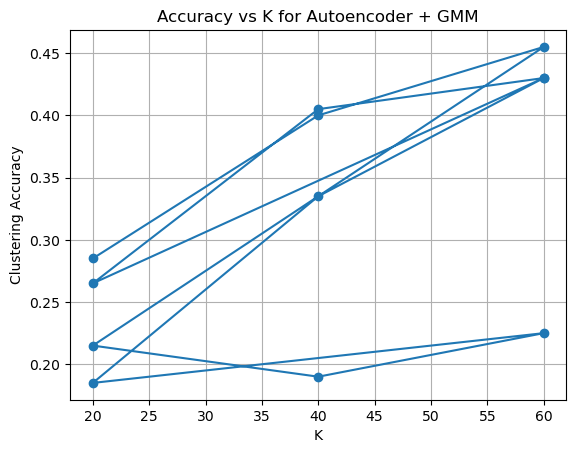

In [513]:
ks = [k for _, _, _, k, acc in results_gmm_autoencoder]
accs = [acc for _, _, _, k, acc in results_gmm_autoencoder]

plt.plot(ks, accs, marker='o')
plt.xlabel('K')
plt.ylabel('Clustering Accuracy')
plt.title('Accuracy vs K for Autoencoder + GMM')
plt.grid()
plt.show()

### Evaluate Best GMM on Test Set for Autoencoder

Best K: 60, Accuracy: 0.4550, Hidden Dim: 100, Learning Rate: 0.05, Epochs: 60
Test Accuracy: 0.0250
Test F1 Score: 0.0000


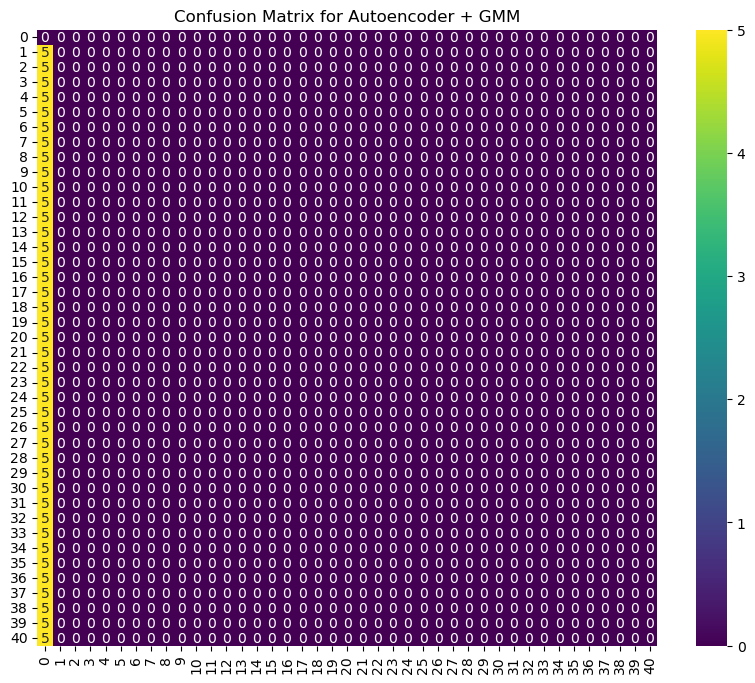

In [514]:
best_dim, best_lr, best_dim, best_epochs, best_acc = max(results_gmm_autoencoder, key=lambda x: x[4])
print(f"Best K: {best_K}, Accuracy: {best_acc:.4f}, Hidden Dim: {best_dim}, Learning Rate: {best_lr}, Epochs: {best_epochs}")

# Train best GMM again
gmm_best = GMM(n_components=best_K)
gmm_best.fit(D_train_encoded)

# Predict on encoded test set
y_pred_test = gmm_best.predict(D_test_encoded)

# Evaluate
acc = clustering_accuracy(y_test, y_pred_test)
print(f"Test Accuracy: {acc:.4f}")

f1 = f1_score(y_test, y_pred_test, average='macro')
print(f"Test F1 Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', cbar=True)
plt.title('Confusion Matrix for Autoencoder + GMM')
plt.show()
